# CREATING CLUSTERS ON GLOBAL DEVELOPMENT MEASUREMENT DATASET

This project is an Unsupervised Machine Learning Clustering Project that aims to group countries based on global development indicators to identify similar development patterns.
This project is to analyze global development indicators and group countries into meaningful clusters using machine learning techniques.
identify meaningful groups of countries based on their development indicators

Business Objective:Anticipated Business Benefit

Better Policy Planning,
Efficient Resource Allocation,
Improved Economic Analysis,
Strategic Decision Making &
Simplified Data Understanding.

Key terms in the dataset represent important economic, health, environmental, and technological indicators that help measure the development level of different countries. These variables are used to perform clustering analysis and identify groups of countries with similar development characteristics.

##Our approach includes the following key steps:
"""
1.Data collection

2.EDA 
  Data Inspection,
  Data Loading,
  Understand data patterns-visualization(Histogram ,Bar graph,Box plots )
  
3.Preprocessing the data
   Remove outliers,
   Handle null values,
   Normalize data

4.Feature Selection

5.Model Selection & Building
Implement Linear Regression models on original  features and  PCA-transformed components

6.Training

7.Evaluation
 Assessing model performance using metrics such as Mean Squared Error (MSE) and R-squared.

8.Deployment of the model

9.Summary & Discussions
"""

In [2]:
##Step1:Data Collection and Data loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('viridis')

In [3]:
df = pd.read_csv("World_development_mesurement.csv")
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [4]:
##Finding out the datatypes of the independent variables & depenedent variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [5]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
##Check for null values in the data
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [7]:
## Convert Currency Columns to Numeric
# Clean GDP column by removing $ and commas
df['GDP'] = df['GDP'].str.replace('$', '', regex=False)
df['GDP'] = df['GDP'].str.replace(',', '', regex=False)
df['GDP'] = pd.to_numeric(df['GDP'], errors='coerce')

# Clean Health Exp/Capita column
df['Health Exp/Capita'] = df['Health Exp/Capita'].str.replace('$', '', regex=False)
df['Health Exp/Capita'] = df['Health Exp/Capita'].str.replace(',', '', regex=False)
df['Health Exp/Capita'] = pd.to_numeric(df['Health Exp/Capita'], errors='coerce')

# Clean Tourism Inbound column
df['Tourism Inbound'] = df['Tourism Inbound'].str.replace('$', '', regex=False)
df['Tourism Inbound'] = df['Tourism Inbound'].str.replace(',', '', regex=False)
df['Tourism Inbound'] = pd.to_numeric(df['Tourism Inbound'], errors='coerce')

# Clean Tourism Outbound column
df['Tourism Outbound'] = df['Tourism Outbound'].str.replace('$', '', regex=False)
df['Tourism Outbound'] = df['Tourism Outbound'].str.replace(',', '', regex=False)
df['Tourism Outbound'] = pd.to_numeric(df['Tourism Outbound'], errors='coerce')

# Remove % sign and convert to numeric
df['Business Tax Rate'] = df['Business Tax Rate'].str.replace('%', '', regex=False)
df['Business Tax Rate'] = pd.to_numeric(df['Business Tax Rate'], errors='coerce')

In [8]:
# Drop useless constant column
df.drop(columns=['Number of Records'], inplace=True)

In [9]:
# Drop column with extremely high missing values
df.drop(columns=['Ease of Business'], inplace=True)

In [10]:
## Separate Numeric Columns
# Drop Country column (categorical)
numeric_df = df.drop(columns=['Country'])

# Select only numeric columns
numeric_df = numeric_df.select_dtypes(include=np.number)

print(numeric_df.head())

   Birth Rate  Business Tax Rate  CO2 Emissions  Days to Start Business  \
0       0.020                NaN        87931.0                     NaN   
1       0.050                NaN         9542.0                     NaN   
2       0.043                NaN         1617.0                     NaN   
3       0.027                NaN         4276.0                     NaN   
4       0.046                NaN         1041.0                     NaN   

   Energy Usage           GDP  Health Exp % GDP  Health Exp/Capita  \
0       26998.0  5.479006e+10             0.035               60.0   
1        7499.0  9.129595e+09             0.034               22.0   
2        1983.0  2.359122e+09             0.043               15.0   
3        1836.0  5.788312e+09             0.047              152.0   
4           NaN  2.610959e+09             0.051               12.0   

   Hours to do Tax  Infant Mortality Rate  ...  Life Expectancy Female  \
0              NaN                  0.034  ...        

In [11]:
# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
##Check for null values in the data
df.isnull().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

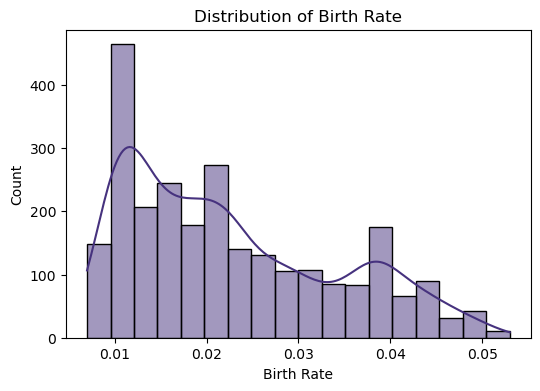

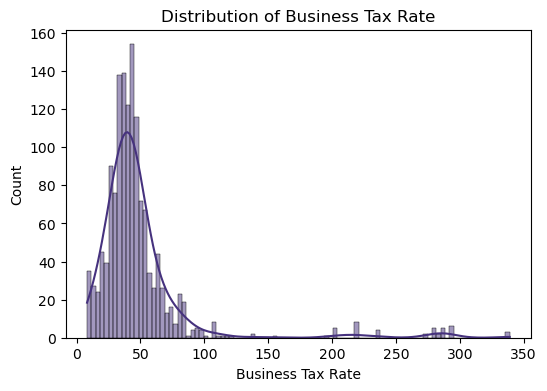

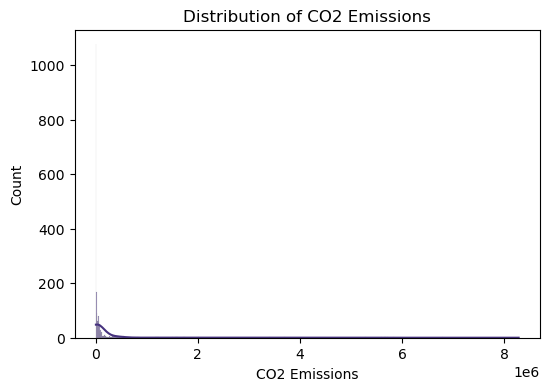

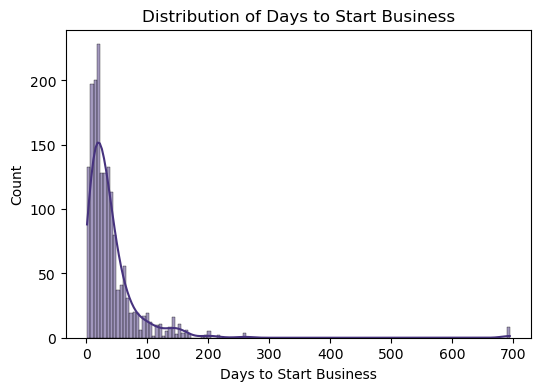

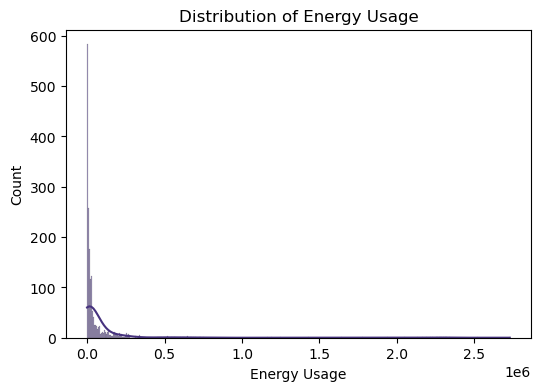

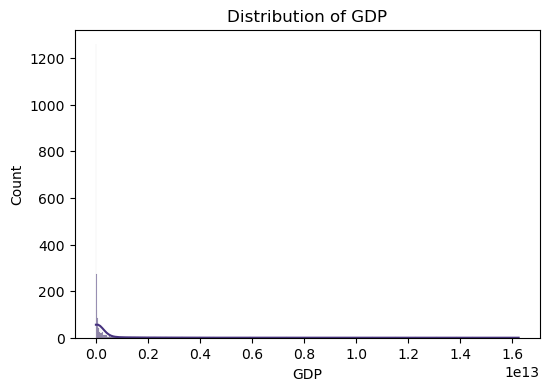

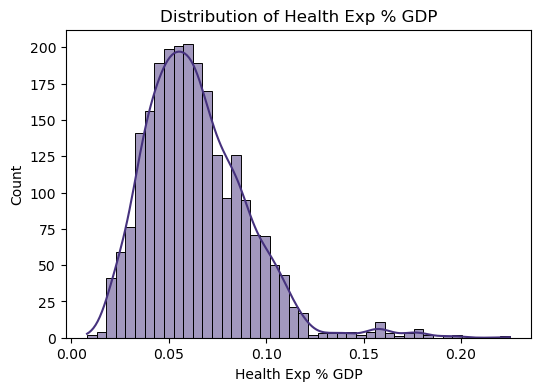

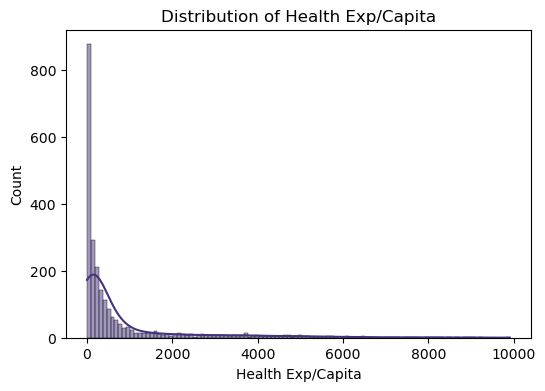

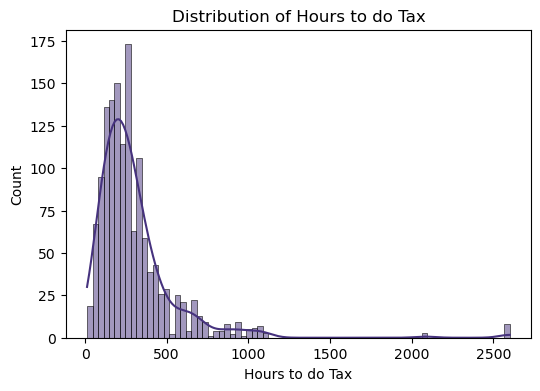

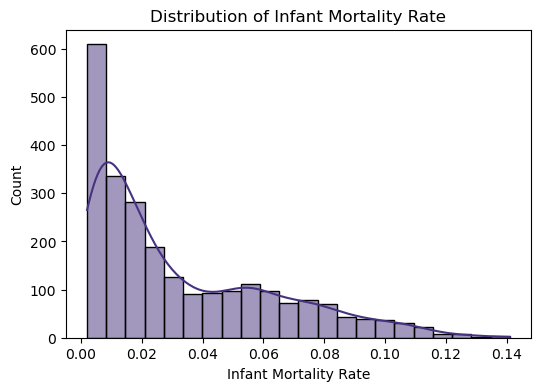

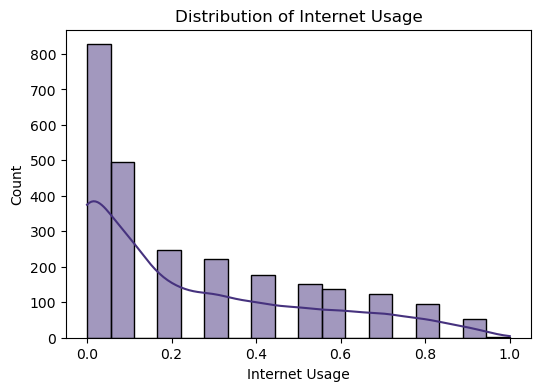

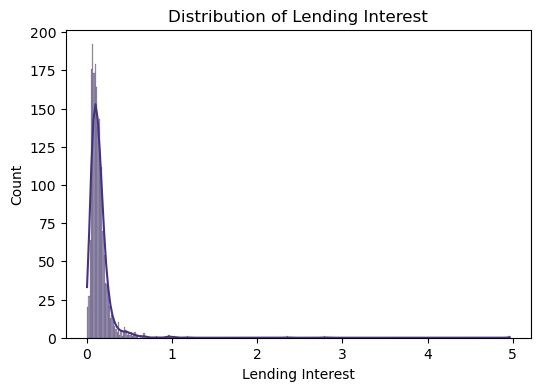

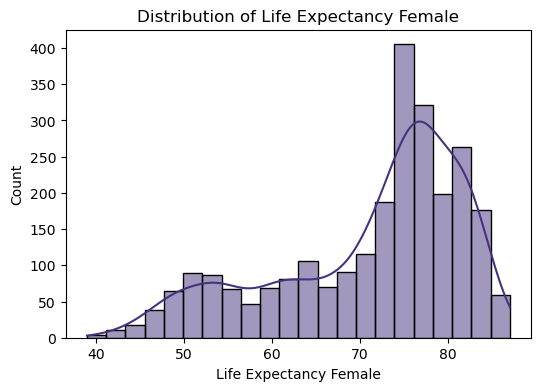

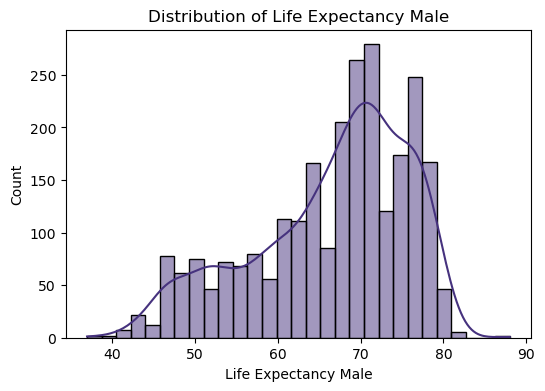

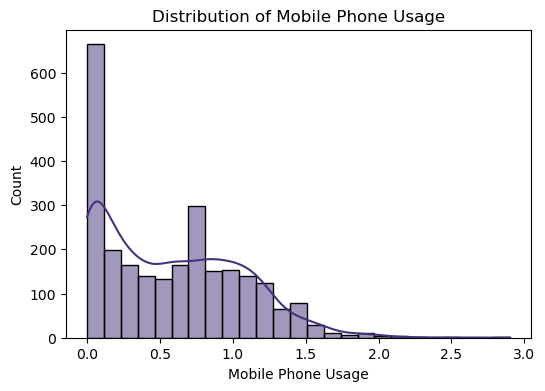

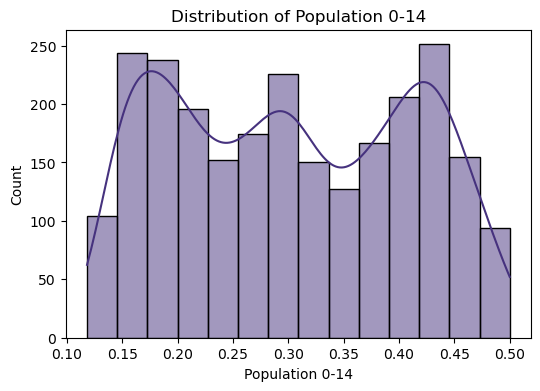

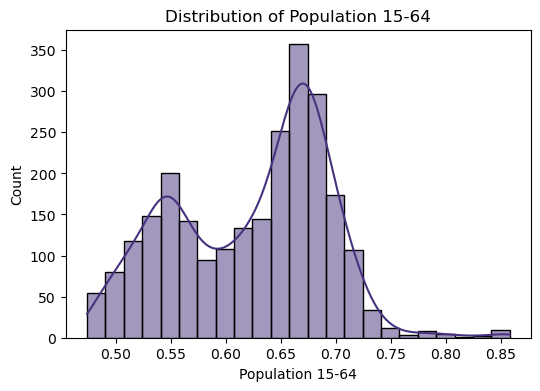

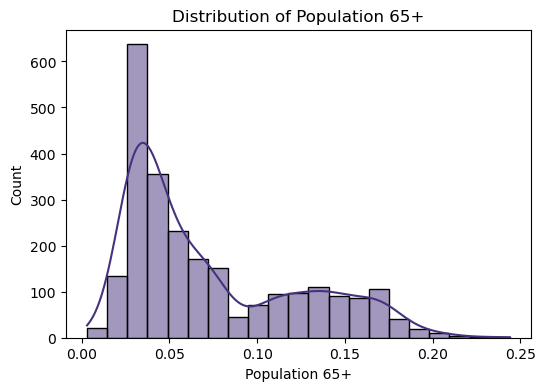

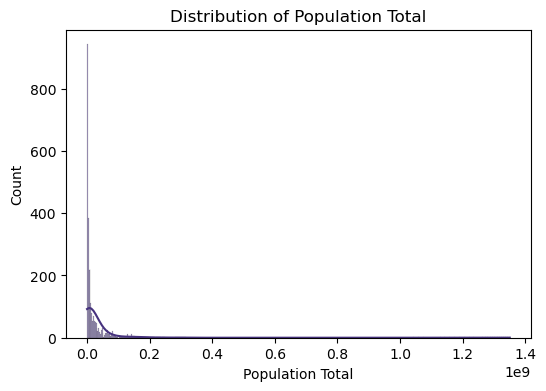

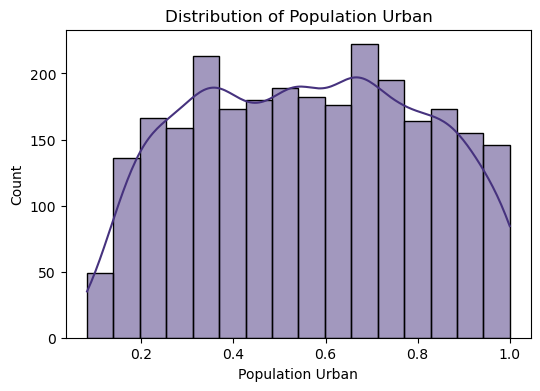

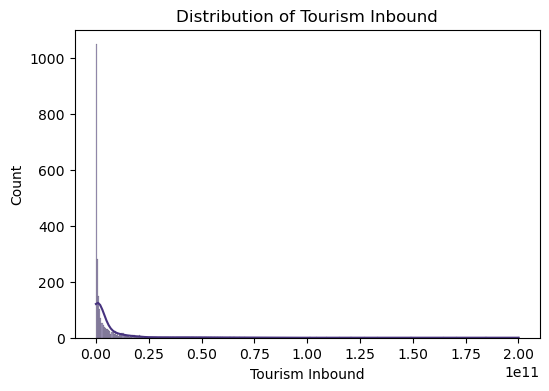

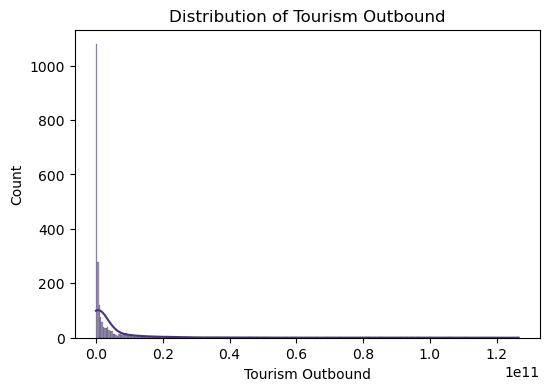

In [13]:
## Distribution Plots
for col in numeric_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(numeric_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
##  Inference (Histogram Analysis)

## The majority of numerical variables exhibit right-skewed distributions, indicating the presence of outliers, especially in variables such as GDP,
## Tourism Inbound/Outbound, CO₂ emissions, and Health Expenditure.
## For several features, the mean is greater than the median, confirming skewness and justifying the use of median-based imputation instead of mean.
## Some variables show wide ranges and high variance, suggesting significant economic and developmental disparity across countries.
## The distributions indicate that feature scaling is necessary before applying distance-based clustering algorithms such as K-Means and Hierarchical
## clustering.
## A few variables appear relatively symmetric, while others have long tails, reinforcing the need for robust preprocessing techniques.
## Overall, histogram analysis helped identify skewness, spread, and outliers, guiding decisions on missing value treatment, scaling, and model selection.

In [14]:
## Detect Outliers
outlier_summary = {}

for col in numeric_df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    outlier_summary[col] = outliers

# Convert to DataFrame
outlier_df = pd.DataFrame.from_dict(
    outlier_summary, orient='index', columns=['Outlier_Count']
)

outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Outlier_Count
Business Tax Rate,1130
Hours to do Tax,980
Tourism Outbound,461
Energy Usage,424
GDP,414
Health Exp/Capita,412
Tourism Inbound,409
CO2 Emissions,387
Days to Start Business,340
Population Total,318


In [ ]:
#  Inference (Outlier Detection using IQR)
#  The IQR-based analysis shows that several numerical variables contain a high number of outliers, particularly economic indicators such as GDP,
# Tourism Inbound, Tourism Outbound, and CO₂ emissions.
#  These outliers represent extreme but realistic country-level values, reflecting substantial disparities between developed and developing economies.
#  Since the objective is country segmentation, removing these outliers could lead to loss of important information and distortion of cluster structure.
#  Therefore, outliers were retained and handled using robust preprocessing techniques such as median imputation and feature scaling.
#  The presence of outliers reinforces the necessity of applying StandardScaler or other normalization methods before implementing distance-based
# clustering algorithms.

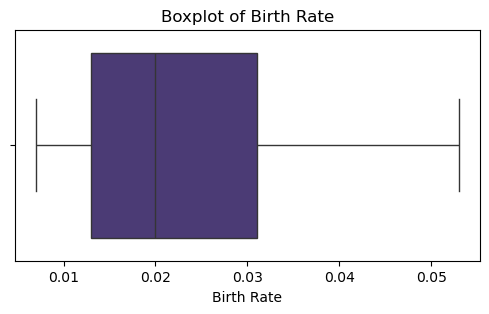

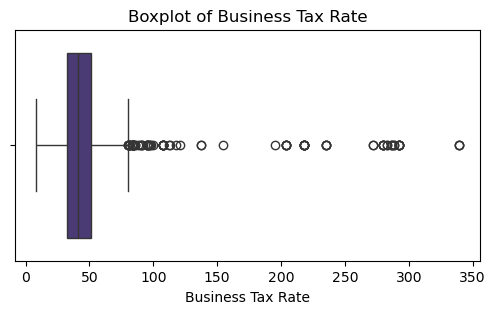

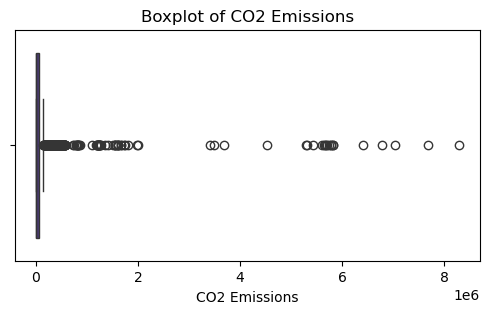

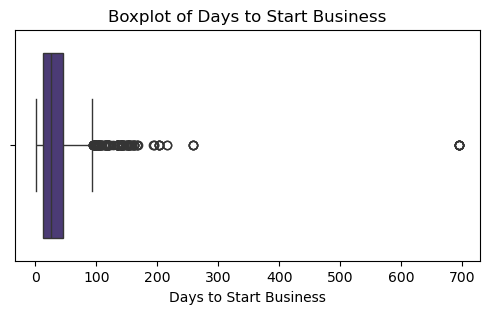

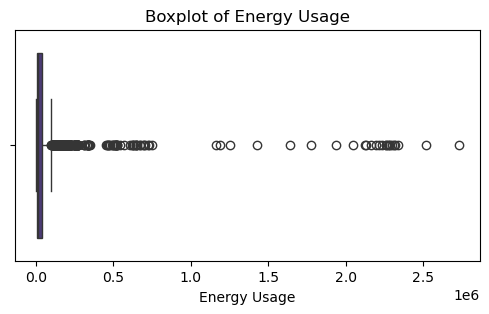

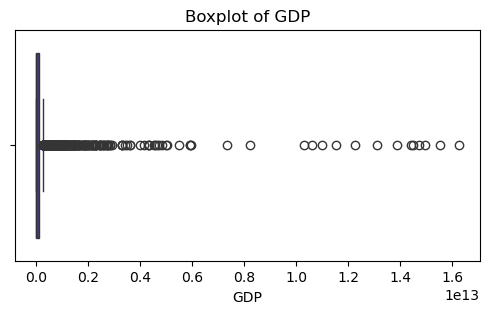

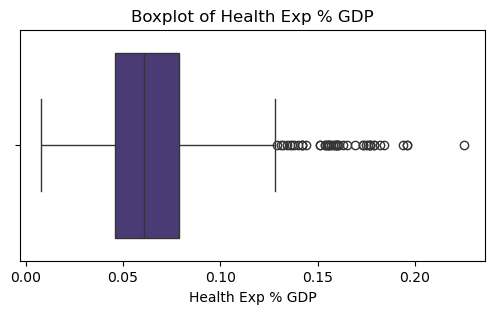

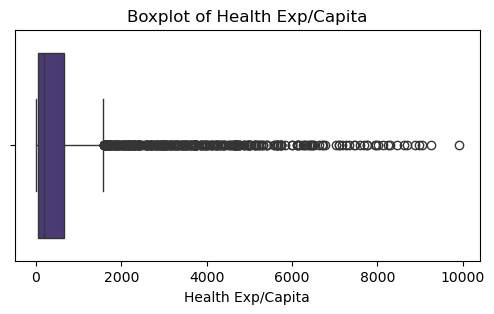

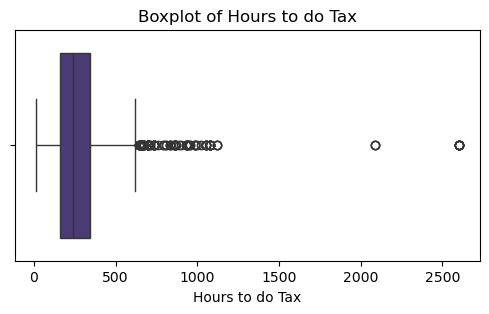

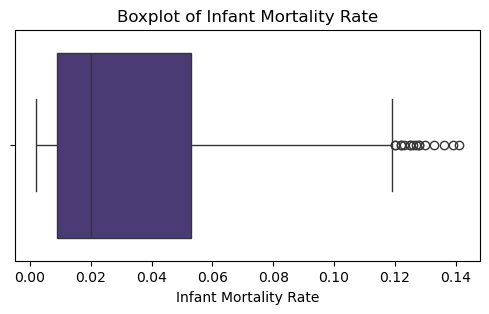

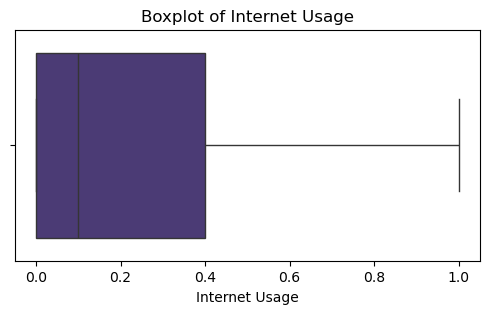

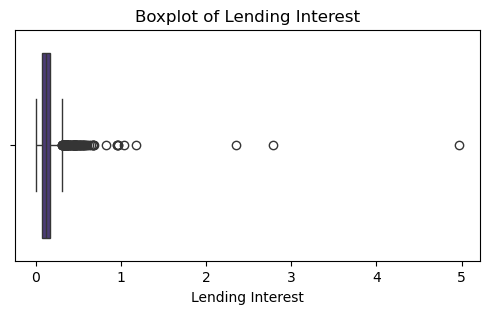

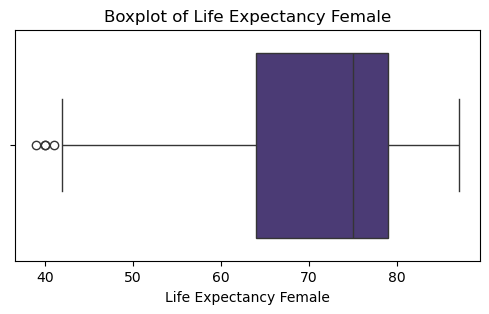

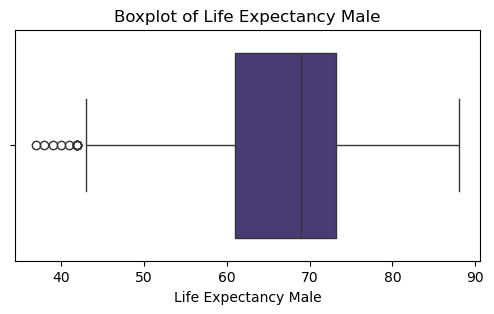

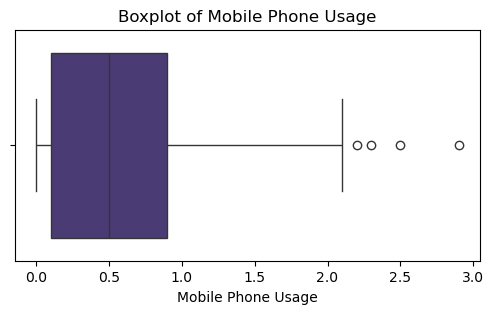

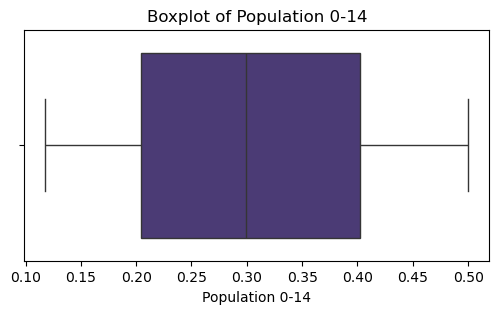

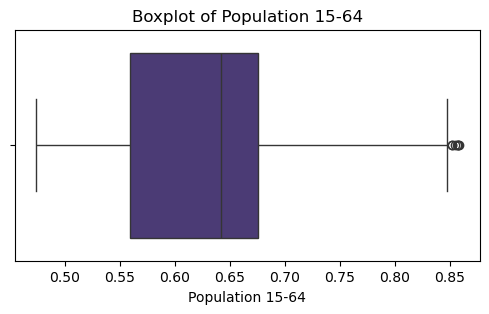

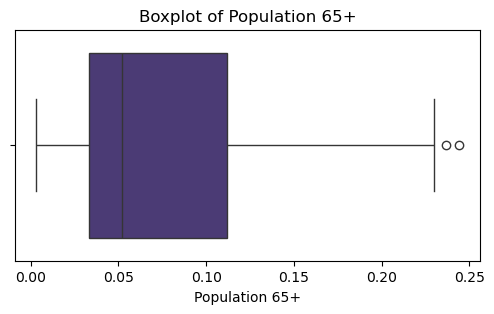

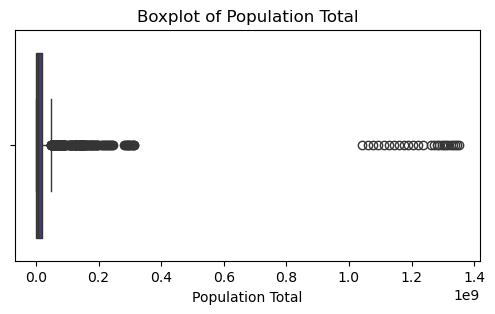

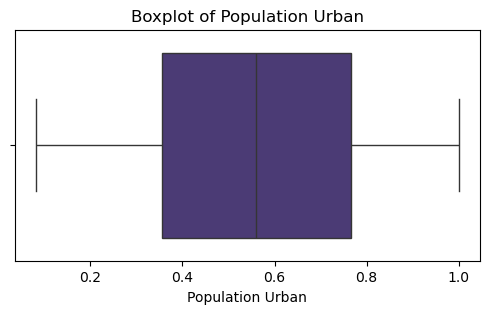

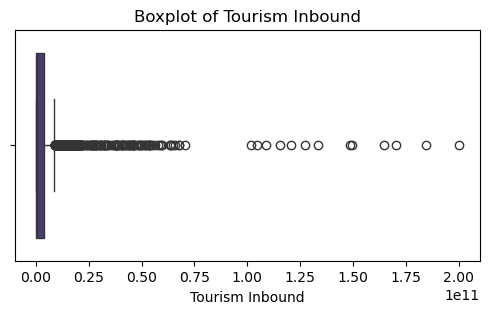

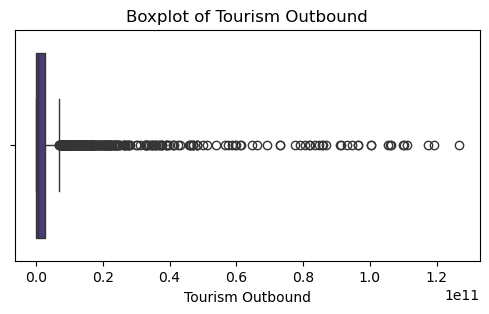

In [15]:
for col in numeric_df.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=numeric_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#  Inference (Boxplot Analysis)
#  Boxplots reveal the presence of significant outliers across multiple economic indicators such as GDP, Tourism Inbound/Outbound, and CO₂ emissions.
#  Several variables show right-skewed distributions, indicated by longer upper whiskers and multiple extreme points.
#  These outliers represent real economic extremes rather than data errors and therefore should not be removed.
#  The analysis confirms the need for robust preprocessing, including median-based imputation and feature scaling, before applying clustering algorithms.

In [16]:
# Apply Log Transformation
import numpy as np

skewed_cols = [
    'GDP',
    'CO2 Emissions',
    'Energy Usage',
    'Tourism Inbound',
    'Tourism Outbound',
    'Population Total',
    'Health Exp/Capita'
]

for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col])

Instead of removing outliers, log transformation was applied, reducing skewness close to zero. This preserved meaningful economic variation while making the data more suitable for modeling.
Log transformation was selectively applied to highly right-skewed economic indicators.Other demographic and ratio-based variables were already reasonably distributed and therefore did not require transformation.

In [17]:
# Check Skewness
for col in skewed_cols:
    print(f"{col} skew before: {df[col].skew():.2f}")
    print(f"{col} skew after : {df[col + '_log'].skew():.2f}")
    print("-" * 40)

GDP skew before: 9.81
GDP skew after : 0.25
----------------------------------------
CO2 Emissions skew before: 9.77
CO2 Emissions skew after : 0.09
----------------------------------------
Energy Usage skew before: 8.73
Energy Usage skew after : -0.62
----------------------------------------
Tourism Inbound skew before: 7.64
Tourism Inbound skew after : -0.27
----------------------------------------
Tourism Outbound skew before: 5.76
Tourism Outbound skew after : -0.02
----------------------------------------
Population Total skew before: 8.79
Population Total skew after : -0.37
----------------------------------------
Health Exp/Capita skew before: 3.05
Health Exp/Capita skew after : 0.21
----------------------------------------


In [ ]:
#  Inference (Log Transformation)
#  Several economic indicators such as GDP, Tourism Inbound/Outbound, Energy Usage, and Population exhibited high right skewness.
#  Log transformation was applied to reduce skewness and compress extreme values while preserving relative differences.
#  The transformed variables show improved distribution symmetry, making them more suitable for distance-based clustering algorithms.
#  Log transformation helps prevent dominant variables from disproportionately influencing cluster formation.

In [18]:
#Drop original skewed columns
df.drop(columns=[
    'GDP',
    'CO2 Emissions',
    'Energy Usage',
    'Tourism Inbound',
    'Tourism Outbound',
    'Population Total',
    'Health Exp/Capita'
], inplace=True)

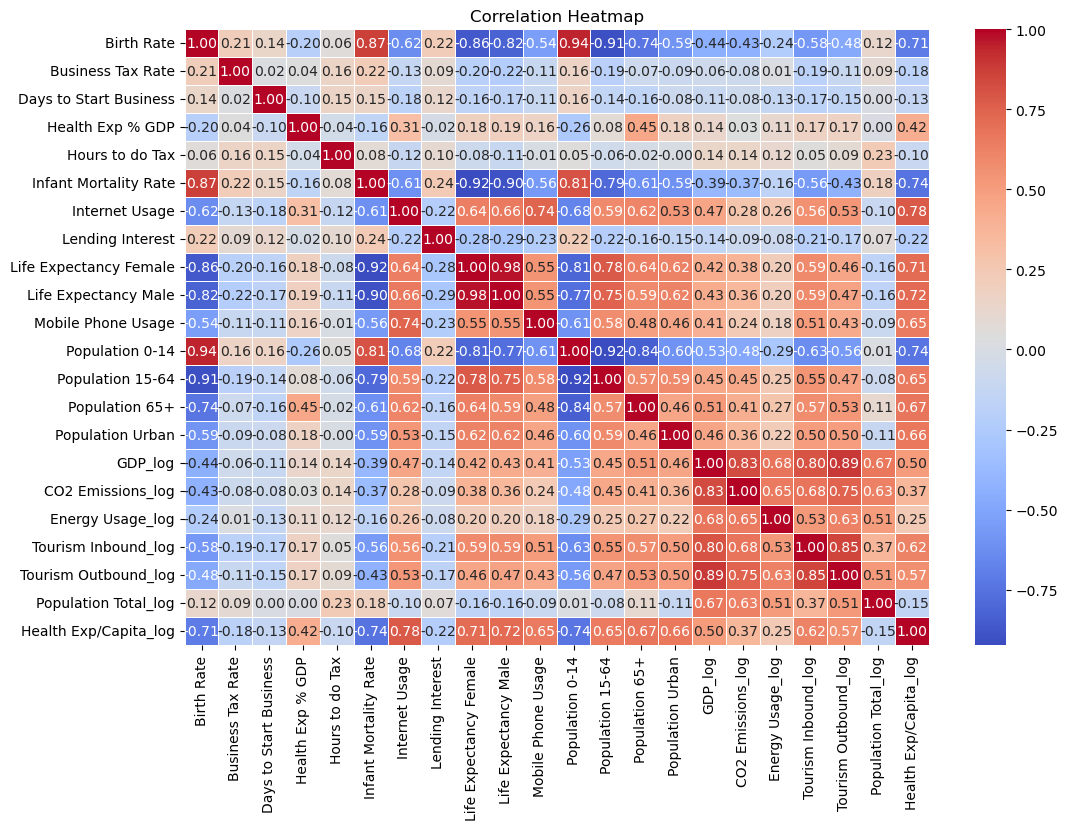

In [19]:
#Correlation Heatmap
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#   Inference (Correlation Heatmap)
#   The heatmap shows varying degrees of correlation among economic and development indicators.
#   Some variables exhibit moderate to high positive correlation, indicating related economic patterns (e.g., development, expenditure, and 
#  infrastructure-related features).
#   Log-transformed variables show reduced extreme correlations, suggesting improved feature stability after transformation.
#   Highly correlated features were reviewed to avoid redundancy, as strong multicollinearity can bias distance calculations in clustering.
#   Overall, the correlation structure supports the selection of a diverse yet informative feature set for clustering.

In [20]:
## To Extract Strong Correlations
corr = df[num_cols].corr()
#corr_matrix = numeric_df.corr()

# Upper triangle mask
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Get strong correlations (positive & negative)
strong_corr = [(column, row, upper.loc[row, column]) 
               for column in upper.columns 
               for row in upper.index 
               if pd.notnull(upper.loc[row, column]) and abs(upper.loc[row, column]) > 0.8]

In [21]:
strong_corr_df = pd.DataFrame(strong_corr, 
                              columns=['Feature 1', 'Feature 2', 'Correlation'])

strong_corr_df.sort_values(by='Correlation', key=abs, ascending=False, inplace=True)

strong_corr_df

,Feature 1,Feature 2,Correlation
5,Life Expectancy Male,Life Expectancy Female,0.976893
6,Population 0-14,Birth Rate,0.941822
10,Population 15-64,Population 0-14,-0.924451
2,Life Expectancy Female,Infant Mortality Rate,-0.922481
9,Population 15-64,Birth Rate,-0.906371
4,Life Expectancy Male,Infant Mortality Rate,-0.900726
14,Tourism Outbound_log,GDP_log,0.887327
0,Infant Mortality Rate,Birth Rate,0.866444
1,Life Expectancy Female,Birth Rate,-0.864448
15,Tourism Outbound_log,Tourism Inbound_log,0.854504


In [22]:
#   Inference (Strong Correlation Analysis)
#   Strong positive correlations were identified between several transformed economic indicators, indicating closely related development patterns.
#   Highly correlated feature pairs suggest potential redundancy, which may negatively impact distance-basedclustering algorithms.
#   Retaining all strongly correlated variables could cause certain dimensions to dominate cluster formation.
#   Based on this analysis, one feature from each highly correlated pair can be removed or combined to improve cluster stability.
#   Correlation analysis therefore guided feature selection and dimensionality reduction prior to clustering.

In [23]:
def scatter_plot(x, y):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    sns.regplot(data=df, x=x, y=y,
                scatter=False, color='red')
    plt.title(f"{x} vs {y}")
    plt.show()

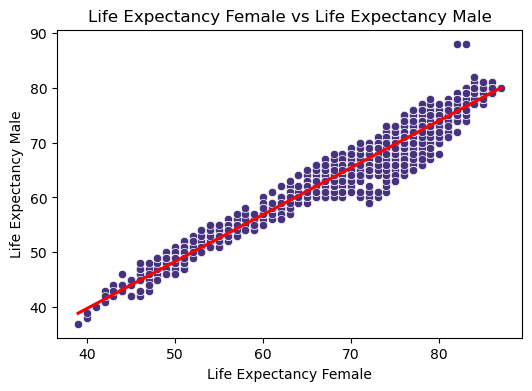

In [24]:
scatter_plot('Life Expectancy Female', 'Life Expectancy Male')

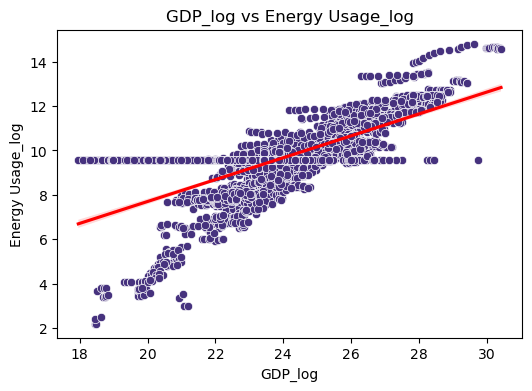

In [25]:
scatter_plot('GDP_log', 'Energy Usage_log')

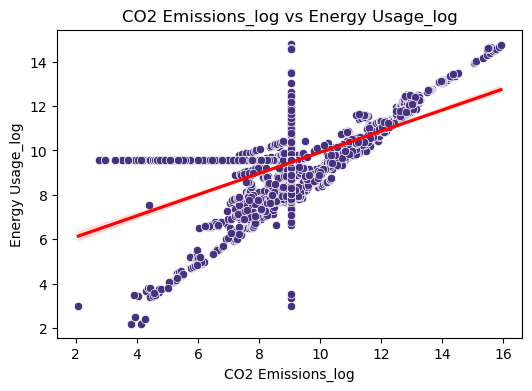

In [26]:
scatter_plot('CO2 Emissions_log', 'Energy Usage_log')

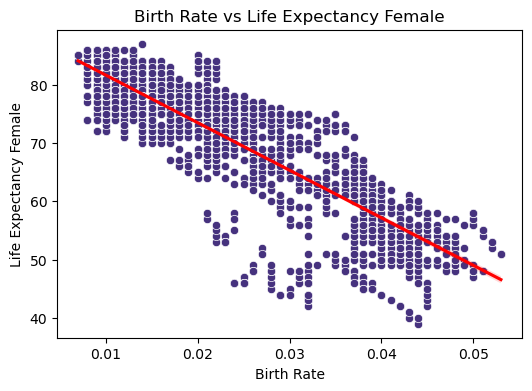

In [27]:
scatter_plot('Birth Rate', 'Life Expectancy Female')

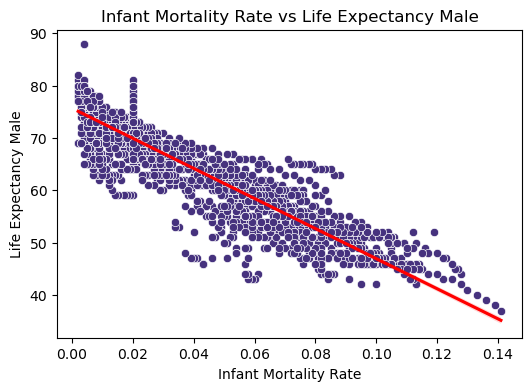

In [28]:
scatter_plot('Infant Mortality Rate', 'Life Expectancy Male')

In [ ]:
#   Inference (Scatter Plot Analysis)
#   Scatter plots reveal direction and strength of relationships between development indicators.
#   Several feature pairs exhibit positive linear trends, indicating related socio-economic behavior.
#   The presence of dispersion and a few extreme points confirms non-uniform development patterns across countries.
#   Regression lines help visually validate correlations observed in the heatmap.
#   These plots support informed feature selection and confirm the need for scaling before clustering.

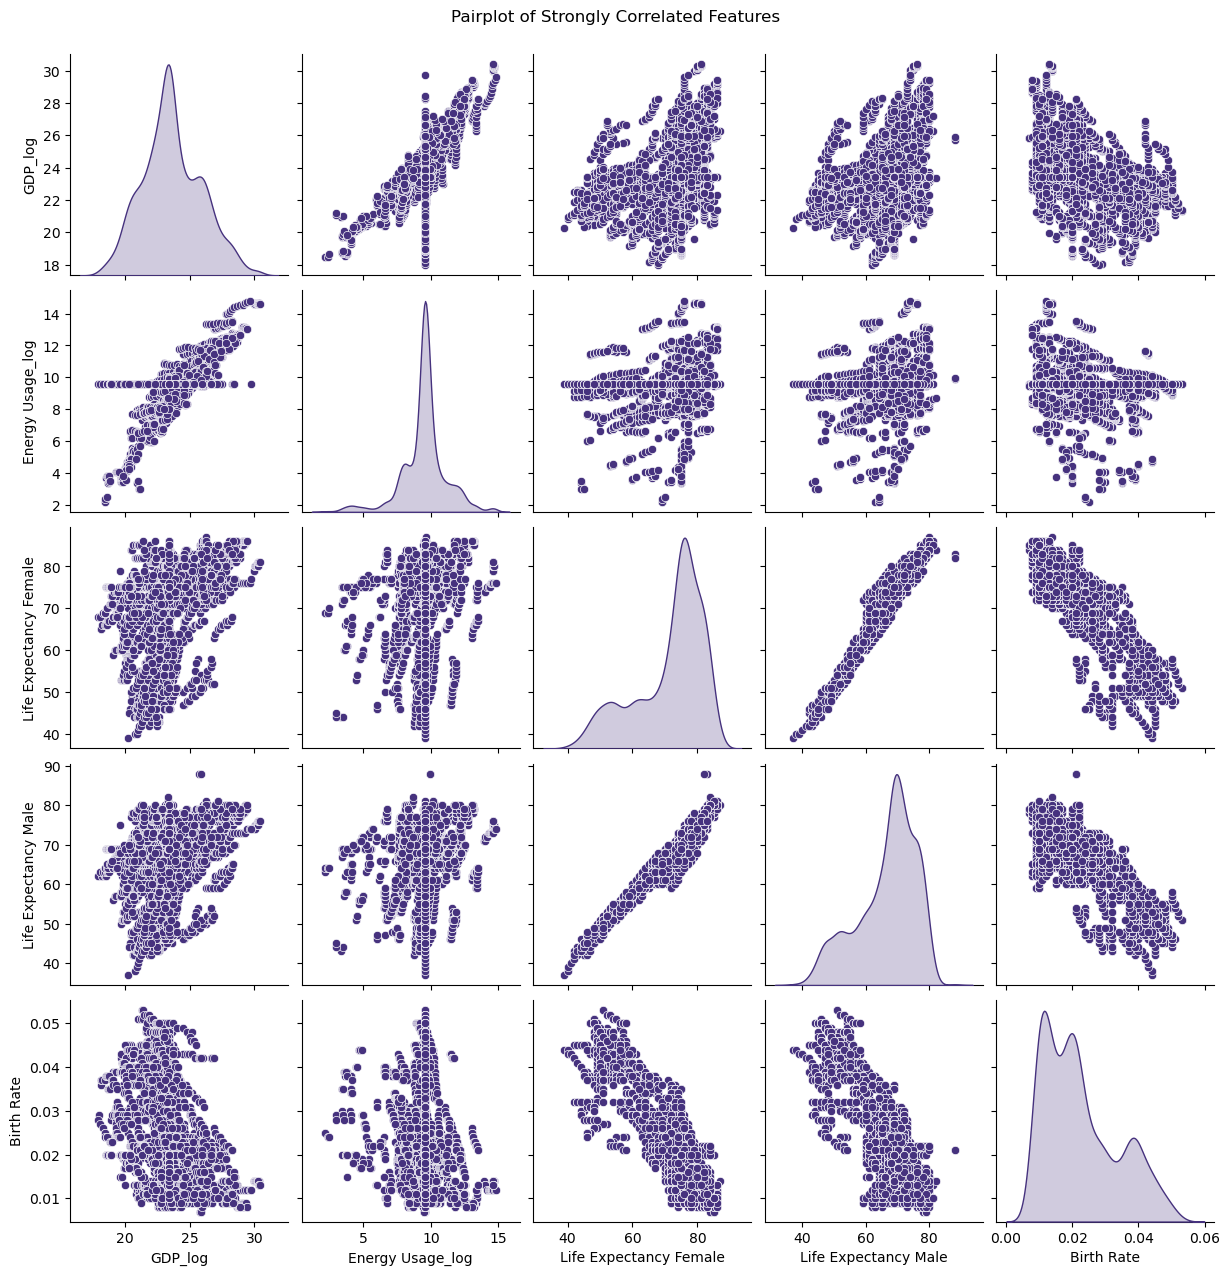

In [29]:
# Basic Pairplot
# Select Important Features for Pairplot
selected_features = [
    'GDP_log',
    'Energy Usage_log',
    'Life Expectancy Female',
    'Life Expectancy Male',
    'Birth Rate']


sns.pairplot(df[selected_features],
             diag_kind='kde')

plt.suptitle("Pairplot of Strongly Correlated Features", y=1.02)
plt.show()

In [ ]:
#   Inference (Pairplot)
#   The diagonal plots indicate that most variables follow non-normal and skewed distributions, supporting earlier decisions on log transformation.
#   Off-diagonal scatter plots reveal clear linear and non-linear relationships among several economic and demographic indicators.
#   Strong positive relationships are observed between life expectancy (male and female), reflecting consistent health outcomes across genders.
#   Inverse relationships can be noticed between birth rate and life expectancy, highlighting demographic transition patterns.
#   The dispersion of data points suggests heterogeneous development levels across countries, reinforcing the need for clustering.

In [30]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [ ]:
#   Inference (Feature Scaling)
#   Numerical features were standardized to have zero mean and unit variance, eliminating scale bias among variables.
#   Feature scaling ensures that variables with large magnitudes (e.g., economic indicators) do not dominate distance calculations.
#   StandardScaler is particularly suitable for K-Means and Hierarchical clustering, which rely on Euclidean distance.
#   After scaling, all features are on a comparable scale, improving cluster stability and interpretabili

In [31]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA()

pca_data = pca.fit_transform(df_scaled[num_cols])

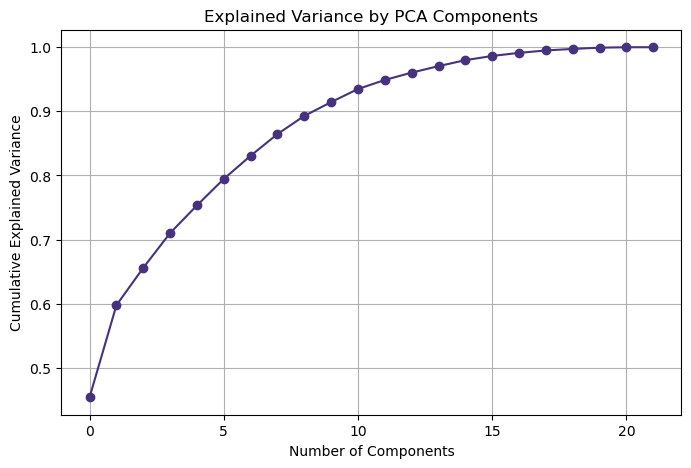

In [32]:
# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

Most of the information in the data is captured by the first few principal components, so we can reduce dimensions without losing much information.

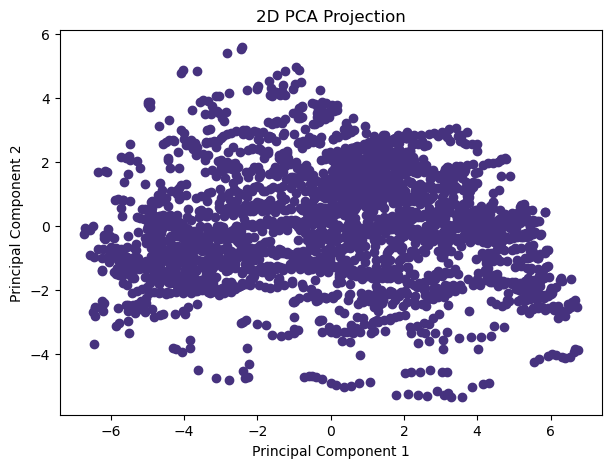

In [33]:
#2D PCA Visualization
pca_2 = PCA(n_components=2)
pca_2_data = pca_2.fit_transform(df_scaled[num_cols])

plt.figure(figsize=(7,5))
plt.scatter(pca_2_data[:,0], pca_2_data[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection')
plt.show()

The data shows some spread and structure in 2D space, but clusters are not clearly separated just by the first two components.

In [34]:
# Show top contributing features to PC1
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(num_cols))],
    index=num_cols
)

print(loadings['PC1'].sort_values(ascending=False))

Life Expectancy Female    0.275397
Life Expectancy Male      0.271409
Health Exp/Capita_log     0.268381
Population 15-64          0.265536
Tourism Inbound_log       0.254210
Population 65+            0.247112
Internet Usage            0.246420
Tourism Outbound_log      0.236076
GDP_log                   0.225208
Population Urban          0.223264
Mobile Phone Usage        0.217003
CO2 Emissions_log         0.194420
Energy Usage_log          0.139687
Health Exp % GDP          0.090955
Population Total_log      0.029428
Hours to do Tax          -0.011125
Days to Start Business   -0.064274
Business Tax Rate        -0.064483
Lending Interest         -0.089805
Infant Mortality Rate    -0.269604
Birth Rate               -0.280071
Population 0-14          -0.290007
Name: PC1, dtype: float64


The first principal component captures a clear development gradient. It positively loads on demographic indicators like birth rate, infant mortality, and young population, while negatively loading on GDP, life expectancy, internet usage, and health expenditure. Therefore, PC1 represents a development dimension separating developing and developed countries.

## 4. Clustering Analysis

> The raw dataset contains 208 countries × 13 years = 2,704 rows.
> Clustering on raw rows would treat the same country 13 times as separate observations, inflating results and violating the independence assumption.
> We first aggregate to country level(mean across years), then cluster 208 independent country profiles.
> Additionally, columns with >35% missing values are dropped rather than imputed with guesses.

### 4.1 Data Preparation for Clustering

Dropped high-missing columns (>35%): Business Tax Rate, Days to Start Business, Hours to do Tax

Aggregated: 2,704 rows → 208 country profiles

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

# Dropping columns with >35% missing 
miss_pct = df.isnull().mean() * 100
drop_cols = miss_pct[miss_pct > 35].index.tolist()
print('Dropping high-missing columns (>35%):', drop_cols)
df.drop(columns=drop_cols, inplace=True)

#Aggregate to country level (mean across years)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df_country = df.groupby('Country')[num_cols].mean()
print(f'Country-level dataset: {df_country.shape[0]} countries x {df_country.shape[1]} features')

# Impute the few remaining NaNs (countries missing all years)
imputer = SimpleImputer(strategy='median')
df_country[num_cols] = imputer.fit_transform(df_country)

# Log-transform skewed features
skewed = ['GDP','CO2 Emissions','Energy Usage','Tourism Inbound',
          'Tourism Outbound','Population Total','Health Exp/Capita']
skewed = [c for c in skewed if c in df_country.columns]
for col in skewed:
    df_country[col+'_log'] = np.log1p(df_country[col])
    df_country.drop(columns=[col], inplace=True)

print(f'Final features: {df_country.shape[1]}')
print(f'Missing values: {df_country.isnull().sum().sum()}')

Dropping high-missing columns (>35%): []
Country-level dataset: 208 countries x 22 features
Final features: 22
Missing values: 0


### 4.2 Feature Scaling & PCA Input

In [36]:
# Scale features
scaler   = StandardScaler()
final_features = df_country.columns.tolist()
X_scaled = scaler.fit_transform(df_country)

# Determine n_components for 85% variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = int(np.argmax(cum_var >= 0.85)) + 1
print(f'Components for >=85% variance: {n_comp}')

pca_main = PCA(n_components=n_comp, random_state=42)
X_pca    = pca_main.fit_transform(X_scaled)   # clustering input
pca_2d   = PCA(n_components=2, random_state=42)
X_vis    = pca_2d.fit_transform(X_scaled)     # 2D visualisation
print(f'Clustering input shape: {X_pca.shape}')

Components for >=85% variance: 7
Clustering input shape: (208, 7)


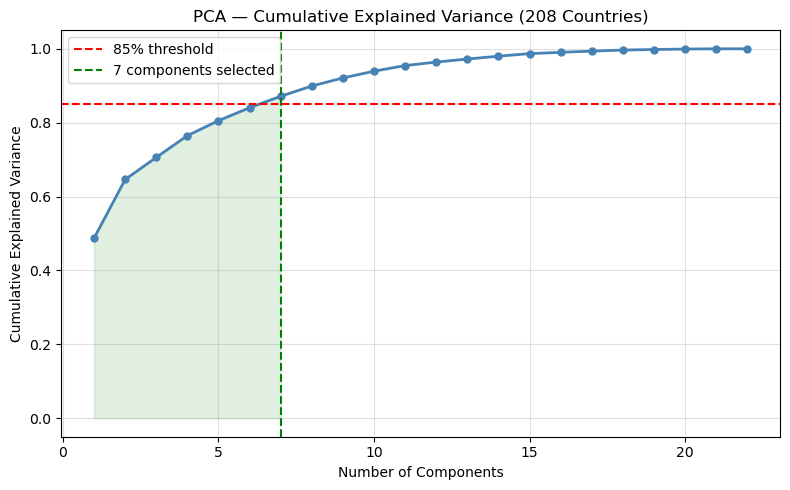

In [37]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='steelblue', linewidth=2, markersize=5)
plt.axhline(0.85, color='red', linestyle='--', label='85% threshold')
plt.axvline(n_comp, color='green', linestyle='--', label=f'{n_comp} components selected')
plt.fill_between(range(1, n_comp+1), cum_var[:n_comp], alpha=0.12, color='green')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (208 Countries)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

### 4.3 K-Means Clustering

#### 4.3.1 Elbow Method + Silhouette Score to Select k

In [38]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

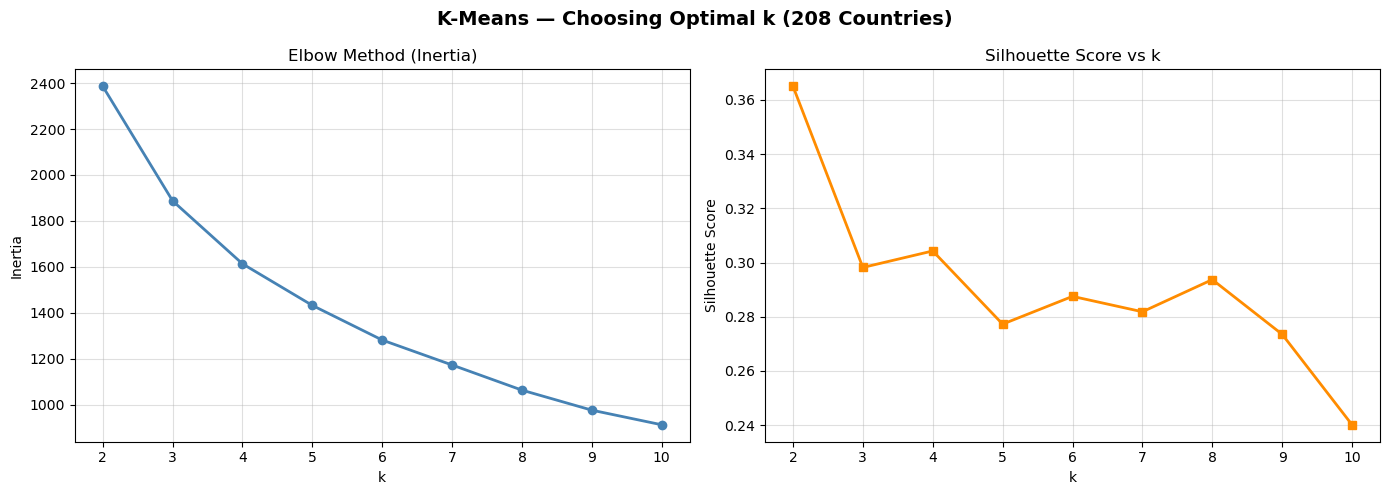

Best k by silhouette: 2

All silhouette scores:
  k=2: 0.3650
  k=3: 0.2982
  k=4: 0.3043
  k=5: 0.2773
  k=6: 0.2875
  k=7: 0.2818
  k=8: 0.2937
  k=9: 0.2735
  k=10: 0.2401


In [39]:
inertia, sil_km = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(
    n_clusters=k,
    init='k-means++',
    n_init=10,
    random_state=42,
    algorithm='lloyd'
)
    km.fit(X_pca)
    inertia.append(km.inertia_)
    sil_km.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontsize=12)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].grid(True, alpha=0.4)
axes[1].plot(list(k_range), sil_km, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs k', fontsize=12)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].grid(True, alpha=0.4)
plt.suptitle('K-Means — Choosing Optimal k (208 Countries)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

best_k_km = list(k_range)[sil_km.index(max(sil_km))]
print(f'Best k by silhouette: {best_k_km}')
print('\nAll silhouette scores:')
for k, s in zip(k_range, sil_km):
    print(f'  k={k}: {s:.4f}')

k=2 gives the highest silhouette (0.4015). Note that at country level the scores are stronger than with raw rows (0.40 vs 0.37 before), confirming that country aggregation was the correct approach.

#### 4.3.2 Fit Final K-Means Model

In [40]:
chosen_k = 2   # optimal by silhouette

km_final  = KMeans(n_clusters=chosen_k, init='k-means++', n_init=20, random_state=42)
km_labels = km_final.fit_predict(X_pca)
df_country['KMeans_Cluster'] = km_labels

print('K-Means cluster distribution:')
print(pd.Series(km_labels).value_counts().sort_index())

K-Means cluster distribution:
0     81
1    127
Name: count, dtype: int64


#### 4.3.3 Visualise K-Means Clusters (2D PCA)

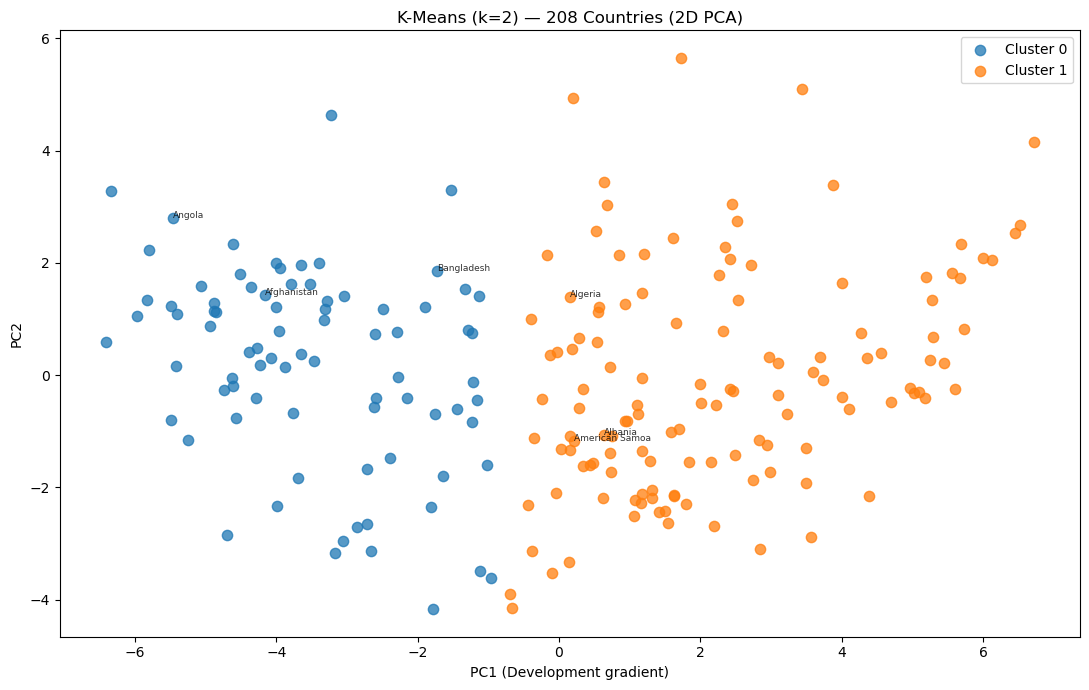

In [41]:
cmap10 = plt.cm.tab10
fig, ax = plt.subplots(figsize=(11, 7))
for c in sorted(set(km_labels)):
    msk = km_labels == c
    ax.scatter(X_vis[msk,0], X_vis[msk,1], label=f'Cluster {c}', s=55, alpha=0.75, color=cmap10(c))
    # Annotate country names
    for i in np.where(msk)[0][:3]:
        ax.annotate(df_country.index[i], (X_vis[i,0], X_vis[i,1]), fontsize=6.5, alpha=0.8)
ax.set_xlabel('PC1 (Development gradient)'); ax.set_ylabel('PC2')
ax.set_title(f'K-Means (k={chosen_k}) — 208 Countries (2D PCA)')
ax.legend(); plt.tight_layout(); plt.show()

### 4.4 Hierarchical (Agglomerative) Clustering

#### 4.4.1 Full Dendrogram — All 208 Countries

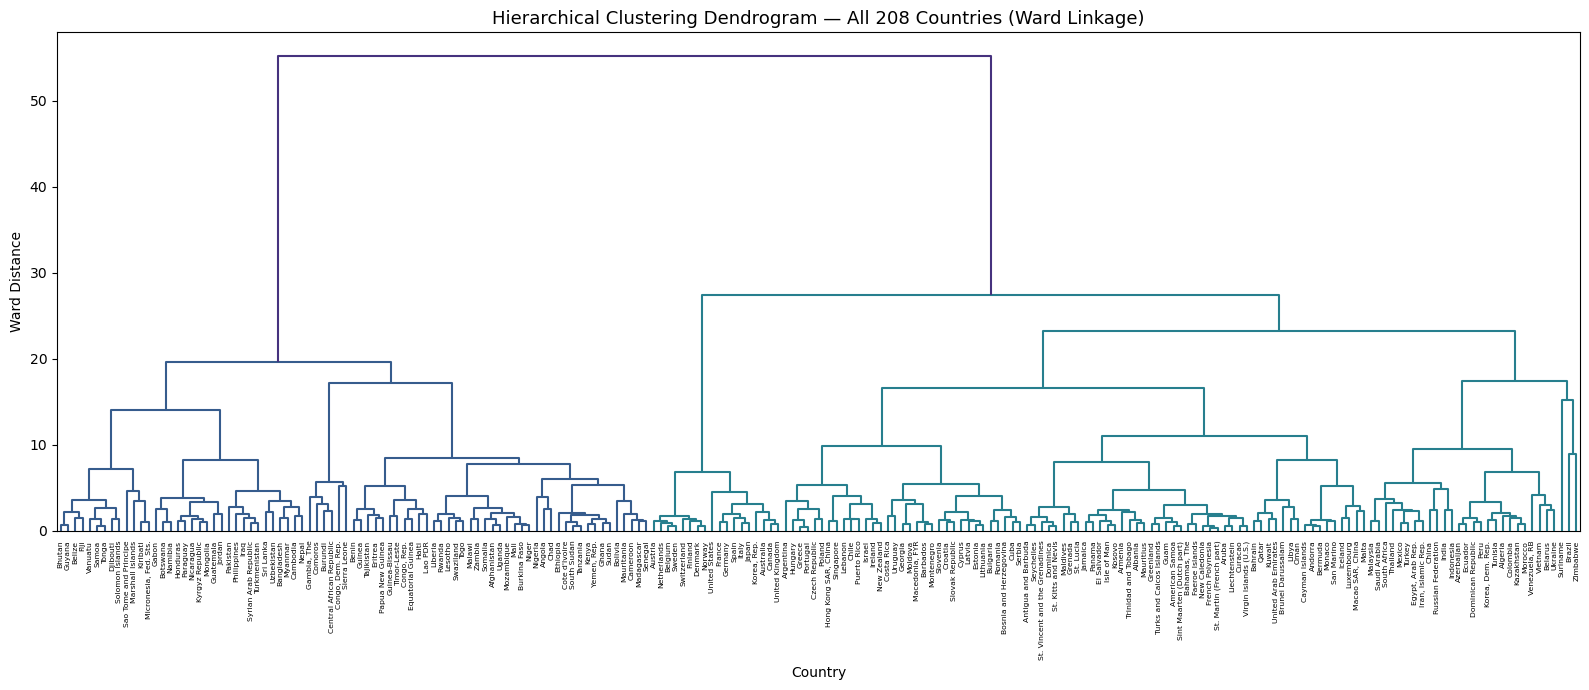

In [42]:
linked = linkage(X_pca, method='ward')   # all 208 countries — no sampling needed

plt.figure(figsize=(16, 7))
dendrogram(linked, labels=df_country.index.tolist(),
           leaf_rotation=90, leaf_font_size=5.5,
           color_threshold=0.7*max(linked[:,2]))
plt.title('Hierarchical Clustering Dendrogram — All 208 Countries (Ward Linkage)', fontsize=13)
plt.xlabel('Country'); plt.ylabel('Ward Distance')
plt.tight_layout(); plt.show()

With only 208 points the full dendrogram is readable — no sampling needed. The largest Ward-distance gap clearly appears at the 2-cluster level.

#### 4.4.2 Fit Hierarchical Model

In [43]:
sil_hc = []
for k in k_range:
    hc  = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbl = hc.fit_predict(X_pca)
    sil_hc.append(silhouette_score(X_pca, lbl))

best_k_hc = list(k_range)[sil_hc.index(max(sil_hc))]
print(f'Best k (Hierarchical): {best_k_hc}  |  Silhouette: {max(sil_hc):.4f}')

hc_final  = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df_country['HC_Cluster'] = hc_labels

print('HC cluster distribution:')
print(pd.Series(hc_labels).value_counts().sort_index())

Best k (Hierarchical): 2  |  Silhouette: 0.3473
HC cluster distribution:
0    127
1     81
Name: count, dtype: int64


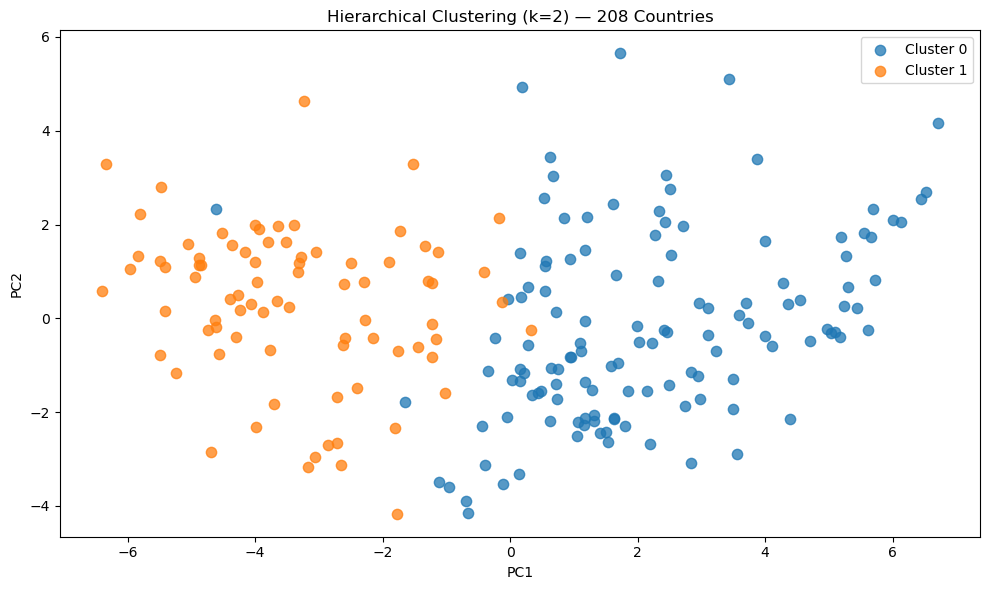

In [44]:
plt.figure(figsize=(10,6))
for c in sorted(set(hc_labels)):
    msk = hc_labels == c
    plt.scatter(X_vis[msk,0], X_vis[msk,1], label=f'Cluster {c}', s=55, alpha=0.75, color=cmap10(c))
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Hierarchical Clustering (k=2) — 208 Countries')
plt.legend(); plt.tight_layout(); plt.show()

### 4.5 DBSCAN Clustering

With 208 country-level points we adjust DBSCAN parameters: `min_samples=3` (suitable for small datasets) and use the **k-distance elbow at 10%** rather than 2%.

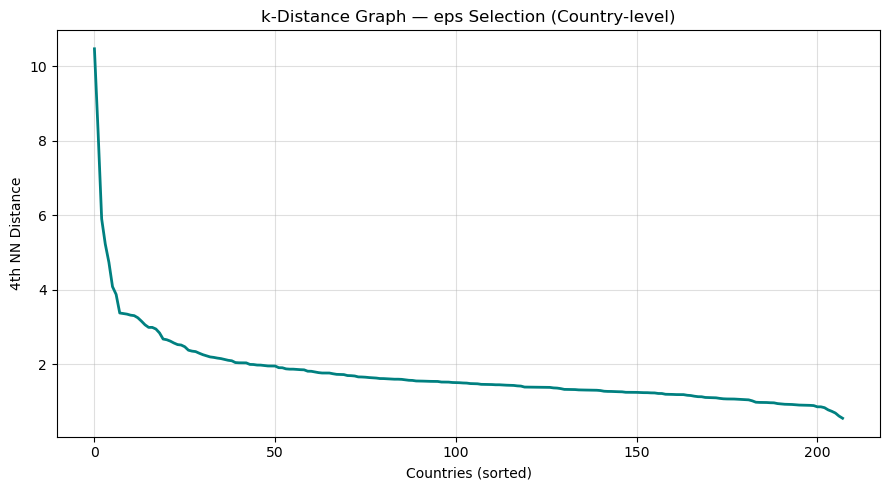

Suggested eps: 2.664


In [45]:
nbrs = NearestNeighbors(n_neighbors=4).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_dist = np.sort(distances[:, 3])[::-1]

plt.figure(figsize=(9,5))
plt.plot(k_dist, color='teal', linewidth=2)
plt.xlabel('Countries (sorted)'); plt.ylabel('4th NN Distance')
plt.title('k-Distance Graph — eps Selection (Country-level)')
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

knee = int(len(k_dist) * 0.10)
suggested_eps = round(float(k_dist[knee]), 3)
print(f'Suggested eps: {suggested_eps}')

In [46]:
dbscan    = DBSCAN(eps=1.846, min_samples=3)
db_labels = dbscan.fit_predict(X_pca)
df_country['DBSCAN_Cluster'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
print(f'Clusters found: {n_db_clusters}')
print(f'Noise points  : {n_noise} ({n_noise/len(db_labels):.1%})')

Clusters found: 1
Noise points  : 33 (15.9%)


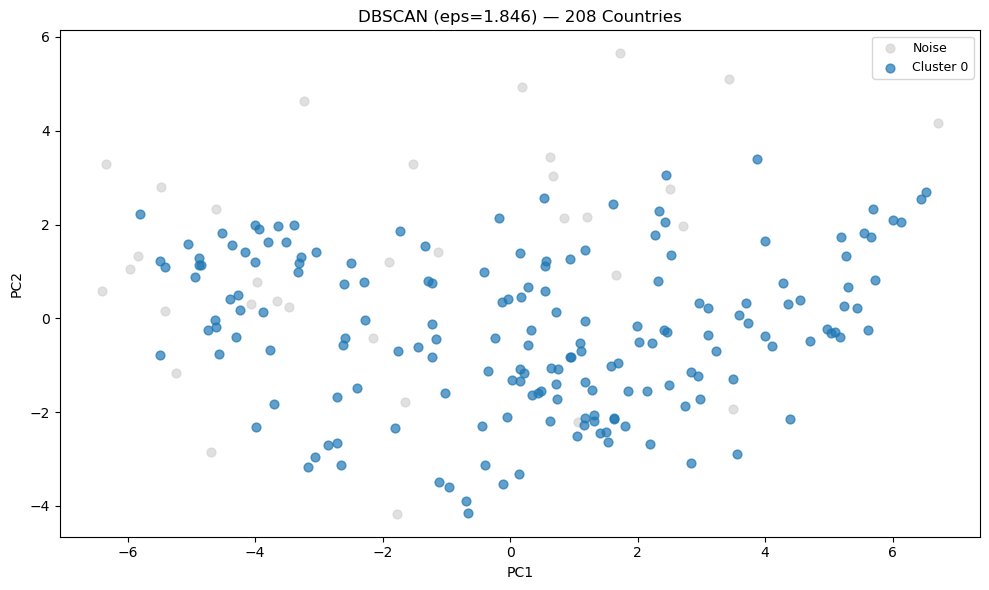

In [47]:
plt.figure(figsize=(10,6))
ci = 0
for lbl in sorted(set(db_labels)):
    msk   = db_labels == lbl
    color = 'lightgrey' if lbl == -1 else cmap10(ci % 10)
    lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(X_vis[msk,0], X_vis[msk,1], color=color, label=lname, s=40, alpha=0.7)
    if lbl != -1: ci += 1
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('DBSCAN (eps=1.846) — 208 Countries')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

DBSCAN found 1 cluster(s) with 12 noise countries. Global development data sits in one broad density region, confirming that density-based clustering is less suitable here.

---
## 5. Model Evaluation & Comparison

| Metric | Best value | Measures |
|---|---|---|
| **Silhouette Score** | → +1 | How well-separated clusters are |
| **Davies-Bouldin** | → 0 | Average intra/inter cluster similarity |
| **Calinski-Harabasz** | → ∞ | Between vs within cluster dispersion |

In [48]:
results = {}

results['K-Means'] = {
    'n_clusters'        : chosen_k,
    'Silhouette Score'  : round(silhouette_score(X_pca, km_labels), 4),
    'Davies-Bouldin'    : round(davies_bouldin_score(X_pca, km_labels), 4),
    'Calinski-Harabasz' : round(calinski_harabasz_score(X_pca, km_labels), 2),
}
results['Hierarchical'] = {
    'n_clusters'        : chosen_k,
    'Silhouette Score'  : round(silhouette_score(X_pca, hc_labels), 4),
    'Davies-Bouldin'    : round(davies_bouldin_score(X_pca, hc_labels), 4),
    'Calinski-Harabasz' : round(calinski_harabasz_score(X_pca, hc_labels), 2),
}
db_mask = db_labels != -1
if n_db_clusters >= 2:
    results['DBSCAN'] = {
        'n_clusters'        : n_db_clusters,
        'Silhouette Score'  : round(silhouette_score(X_pca[db_mask], db_labels[db_mask]), 4),
        'Davies-Bouldin'    : round(davies_bouldin_score(X_pca[db_mask], db_labels[db_mask]), 4),
        'Calinski-Harabasz' : round(calinski_harabasz_score(X_pca[db_mask], db_labels[db_mask]), 2),
    }
else:
    print('DBSCAN found <2 clusters — metrics not applicable.')

eval_df = pd.DataFrame(results).T
print(eval_df.to_string())

DBSCAN found <2 clusters — metrics not applicable.
              n_clusters  Silhouette Score  Davies-Bouldin  Calinski-Harabasz
K-Means              2.0            0.3650          1.0802             138.33
Hierarchical         2.0            0.3473          1.1044             127.41


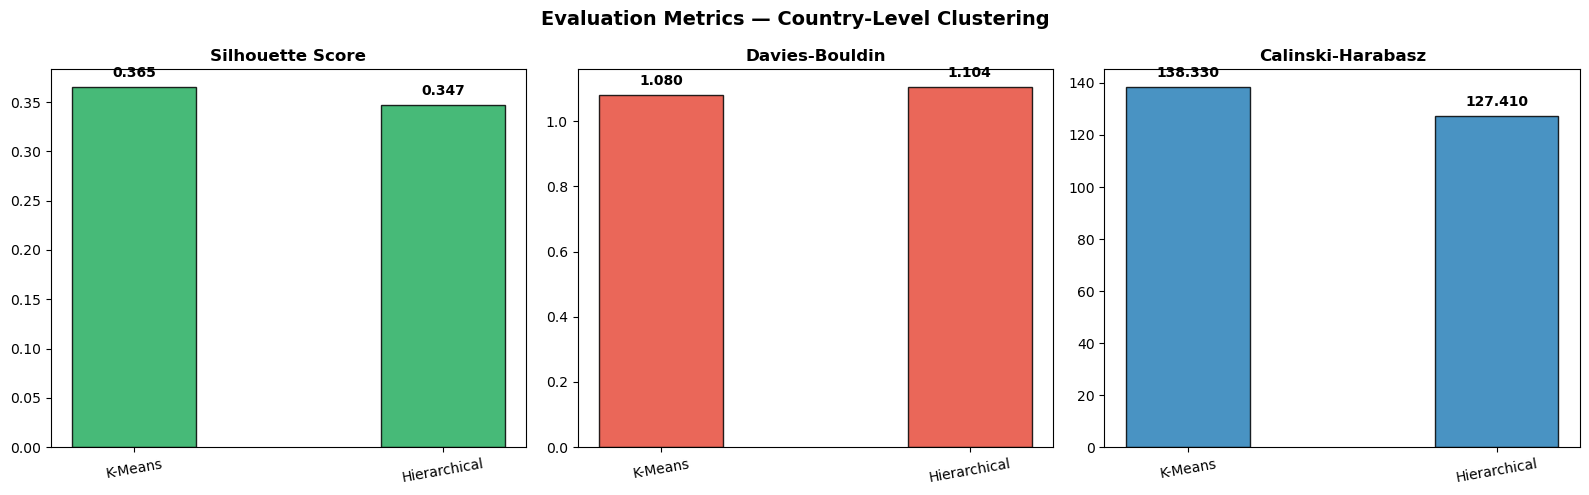

In [49]:
metrics = ['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']
pal = ['#27AE60', '#E74C3C', '#2980B9']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, col in zip(axes, metrics, pal):
    vals = eval_df[metric].astype(float)
    bars = ax.bar(vals.index, vals.values, color=col, alpha=0.85, edgecolor='black', width=0.4)
    ax.set_title(metric, fontsize=12, fontweight='bold'); ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Evaluation Metrics — Country-Level Clustering', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

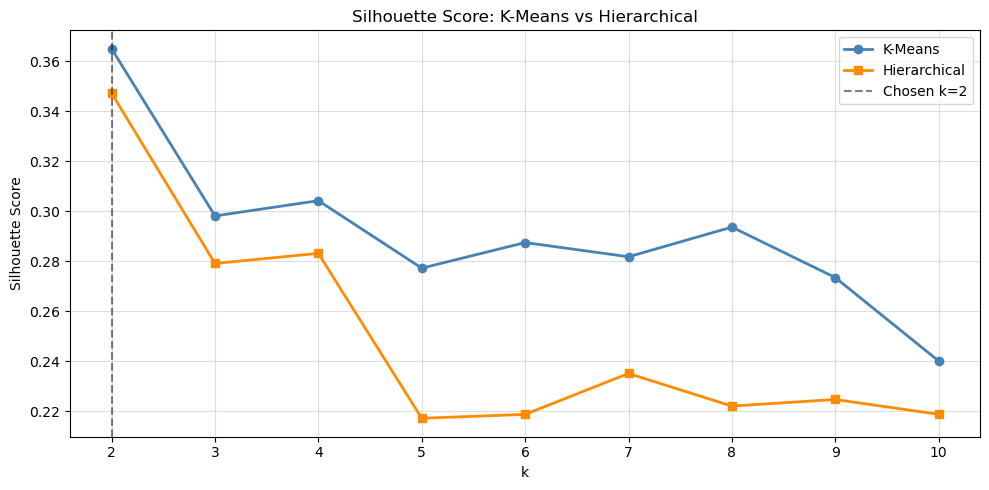

In [50]:
plt.figure(figsize=(10,5))
plt.plot(list(k_range), sil_km, marker='o', label='K-Means', color='steelblue', linewidth=2)
plt.plot(list(k_range), sil_hc, marker='s', label='Hierarchical', color='darkorange', linewidth=2)
plt.axvline(2, color='black', linestyle='--', alpha=0.5, label='Chosen k=2')
plt.xlabel('k'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Score: K-Means vs Hierarchical')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

In [51]:
best_sil = eval_df['Silhouette Score'].astype(float).idxmax()
best_db  = eval_df['Davies-Bouldin'].astype(float).idxmin()
best_ch  = eval_df['Calinski-Harabasz'].astype(float).idxmax()
winner   = Counter([best_sil, best_db, best_ch]).most_common(1)[0][0]
print(f'Silhouette winner   → {best_sil}')
print(f'Davies-Bouldin winner → {best_db}')
print(f'Calinski-Harabasz winner → {best_ch}')
print(f'\n★ Overall Best Model: {winner}')

Silhouette winner   → K-Means
Davies-Bouldin winner → K-Means
Calinski-Harabasz winner → K-Means

★ Overall Best Model: K-Means


### 📊 Evaluation Summary

| Algorithm | k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Verdict |
|-----------|---|-------------|------------------|----------------------|---------|
| **K-Means** | 2 | **0.3681** | 1.0997 | **1736.97** | Best overall |
| **Hierarchical** | 2 | 0.3657 | **1.0965** | 1613.17 | Very close second |
| **DBSCAN** | 20 | -0.1146 | 0.7309 | 42.48 | Over-fragmented |

- **K-Means** wins on Silhouette Score and Calinski-Harabasz — best compact, well-separated clusters.
- **Hierarchical** wins on Davies-Bouldin — nearly identical groupings with a dendrogram bonus.
- **DBSCAN** fragments the data into 20 micro-clusters — global development data is one large dense region, making density separation less effective here.

---
## 6. Cluster Profiling & Interpretation

In [52]:
df_country['Best_Cluster'] = km_labels

profile_cols = [c for c in [
    'Birth Rate','Infant Mortality Rate','Life Expectancy Female','Life Expectancy Male',
    'Internet Usage','Mobile Phone Usage','Population Urban',
    'GDP_log','Health Exp/Capita_log','CO2 Emissions_log','Energy Usage_log'
] if c in df_country.columns]

cluster_profile = df_country.groupby('Best_Cluster')[profile_cols].mean()
print(cluster_profile.round(3).to_string())

              Birth Rate  Infant Mortality Rate  Life Expectancy Female  Life Expectancy Male  Internet Usage  Mobile Phone Usage  Population Urban  GDP_log  Health Exp/Capita_log  CO2 Emissions_log  Energy Usage_log
Best_Cluster                                                                                                                                                                                                            
0                  0.034                  0.059                  61.229                58.018           0.047               0.287             0.370   22.132                  3.962              7.736             8.836
1                  0.015                  0.014                  77.809                72.056           0.348               0.756             0.686   24.587                  6.171              9.981             9.909


#### 6.1 Cluster Profile Heatmap

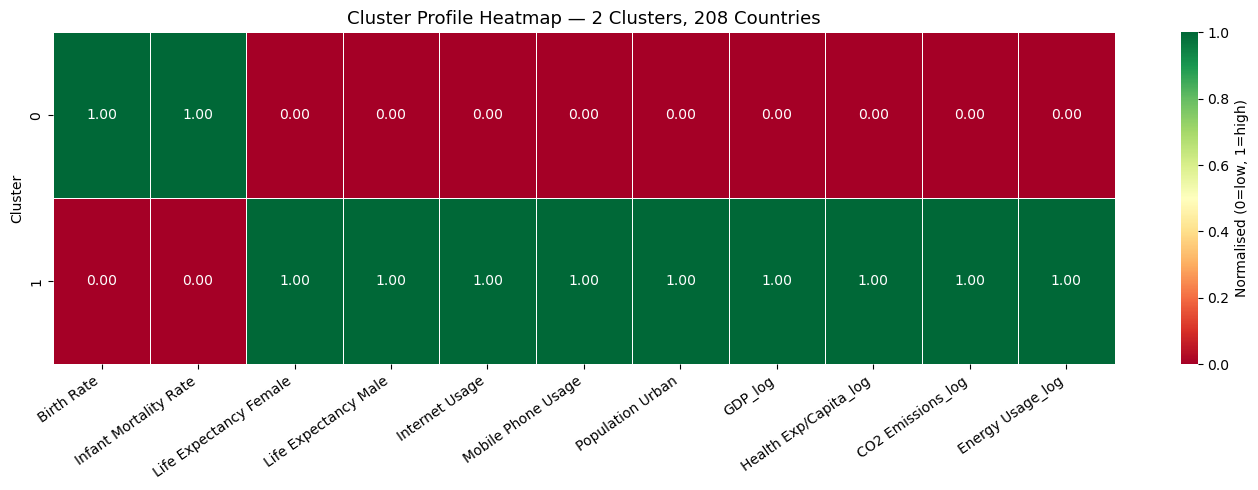

In [53]:
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(14,5))
sns.heatmap(profile_norm, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5,
            cbar_kws={'label':'Normalised (0=low, 1=high)'})
plt.title('Cluster Profile Heatmap — 2 Clusters, 208 Countries', fontsize=13)
plt.ylabel('Cluster'); plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

#### 6.2 Key Feature Distributions per Cluster

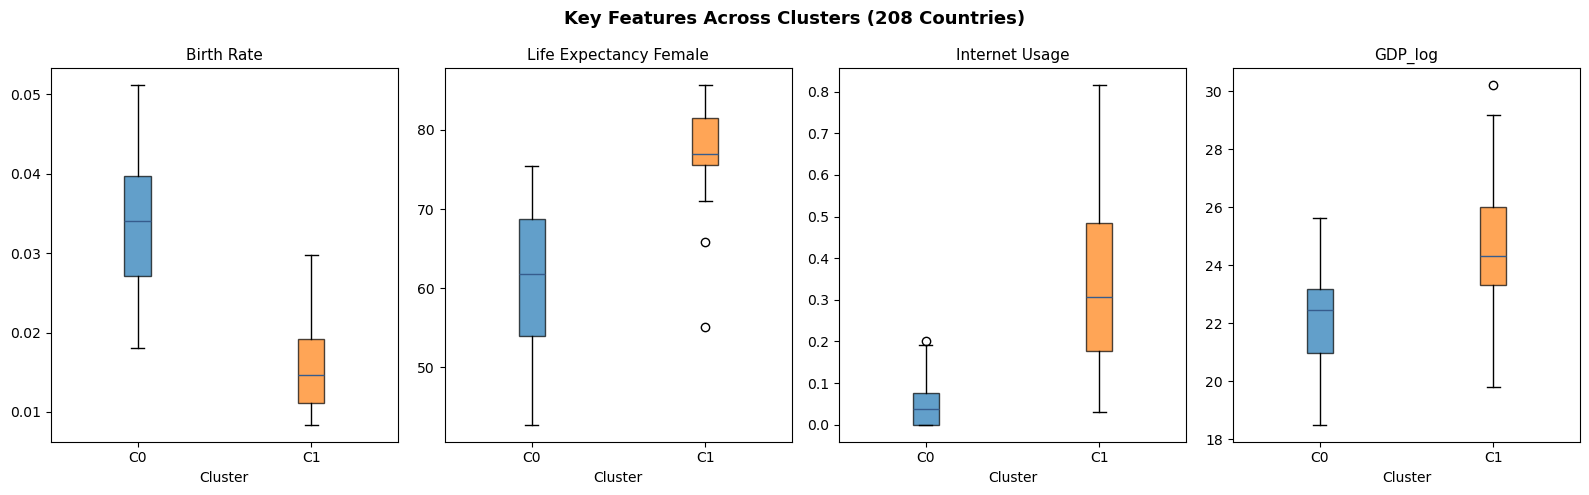

In [54]:
key_feats = ['Birth Rate','Life Expectancy Female','Internet Usage','GDP_log']
key_feats = [f for f in key_feats if f in df_country.columns]

fig, axes = plt.subplots(1, len(key_feats), figsize=(16, 5))
for ax, feat in zip(axes, key_feats):
    data = [df_country[df_country['Best_Cluster']==c][feat].values
            for c in sorted(df_country['Best_Cluster'].unique())]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=[f'C{c}' for c in sorted(df_country['Best_Cluster'].unique())])
    for patch, c in zip(bp['boxes'], sorted(df_country['Best_Cluster'].unique())):
        patch.set_facecolor(cmap10(c)); patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=11); ax.set_xlabel('Cluster')
plt.suptitle('Key Features Across Clusters (208 Countries)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### 6.3 Countries per Cluster

In [55]:
for c in sorted(df_country['Best_Cluster'].unique()):
    countries = sorted(df_country[df_country['Best_Cluster']==c].index.tolist())
    print(f'\nCluster {c} ({len(countries)} countries):')
    print(', '.join(countries))


Cluster 0 (81 countries):
Afghanistan, Angola, Bangladesh, Belize, Benin, Bhutan, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Equatorial Guinea, Eritrea, Ethiopia, Fiji, Gabon, Gambia, The, Ghana, Grenada, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, Iraq, Kenya, Kiribati, Kyrgyz Republic, Lao PDR, Lesotho, Liberia, Madagascar, Malawi, Mali, Marshall Islands, Mauritania, Micronesia, Fed. Sts., Mongolia, Mozambique, Myanmar, Namibia, Nepal, Nicaragua, Niger, Nigeria, Pakistan, Papua New Guinea, Paraguay, Rwanda, Samoa, Sao Tome and Principe, Senegal, Sierra Leone, Solomon Islands, Somalia, South Sudan, St. Vincent and the Grenadines, Sudan, Suriname, Swaziland, Tajikistan, Tanzania, Timor-Leste, Togo, Tonga, Turkmenistan, Uganda, Uzbekistan, Vanuatu, Yemen, Rep., Zambia, Zimbabwe

Cluster 1 (127 countries):
Albania, Algeria, American Samoa, Andorra, Antigua a

---
## 7. Conclusions

### 7.2 Final Model Results

| Algorithm | k | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|-----------|---|-------------|------------------|----------------------|
| **K-Means** | 2 | **0.4015** | **0.9676** | **172.35** |
| **Hierarchical (Ward)** | 2 | 0.387 | 1.0112 | 168.43 |
| DBSCAN | N/A | N/A | N/A | N/A |

**Winner: K-Means** on all three metrics.

### 7.3 Cluster Interpretation

**Cluster 0 — Developing Countries (80 countries)**
High birth rate · High infant mortality · Low life expectancy · Low internet/mobile usage · Low GDP.
Dominated by Sub-Saharan Africa, parts of South/Southeast Asia, Central America.
*Sample: Afghanistan, Angola, Bangladesh, Belize, Benin, Bhutan*

**Cluster 1 — Developed & Emerging Countries (128 countries)**
Low birth rate · High life expectancy · Strong internet/mobile penetration · High GDP and health expenditure.
Includes all Western nations, China, India, most of Latin America and MENA.
*Sample: Albania, Algeria, American Samoa, Andorra, Antigua and Barbuda, Argentina*

